In [ ]:
from ISLP import load_data
Default = load_data('Default')
Default.head()

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138947
3,No,No,529.250605,35704.493935
4,No,No,785.655883,38463.495879


In [ ]:
# ===================================================
# ADABOOST.M1 con dataset "Default" (ISLR)
# Selección del número óptimo de árboles con la Regla del Codo
# ===================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, roc_curve



In [ ]:
# ==========================================
# 1. Cargar dataset "Default"
# ==========================================
url = "Default.csv"
df = pd.read_csv(url)

# Mostrar estructura
print(df.head())
print("\nDistribución de la variable objetivo:")
print(df['default'].value_counts())




  default student      balance        income
0      No      No   729.526495  44361.625074
1      No     Yes   817.180407  12106.134700
2      No      No  1073.549164  31767.138947
3      No      No   529.250605  35704.493935
4      No      No   785.655883  38463.495879

Distribución de la variable objetivo:
default
No     9667
Yes     333
Name: count, dtype: int64


In [ ]:
# ==========================================
# 2. Preprocesamiento
# ==========================================
# Codificar variables categóricas
df['default'] = df['default'].map({'No': 0, 'Yes': 1})
df['student'] = df['student'].map({'No': 0, 'Yes': 1})

# Variables predictoras y objetivo
X = df[['balance', 'income', 'student']]
y = df['default']

# División estratificada para mantener el desbalance original
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)



In [ ]:
# ==========================================
# 3. Entrenar modelos AdaBoost con distinto número de árboles
# ==========================================
n_estimators_range = np.arange(40, 1040, 40)
roc_auc_values = []

for n_estimators in n_estimators_range:
    model = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=n_estimators,
        random_state=42
    )
    model.fit(X_train, y_train)
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_pred_prob)
    roc_auc_values.append(roc_auc)



In [ ]:
# ==========================================
# 4. Aplicar la Regla del Codo
# ==========================================
diffs = np.diff(roc_auc_values)
# Buscamos donde la mejora se hace marginal (< 0.001)
elbow_idx = np.argmax(diffs < 0.001)
optimal_n = n_estimators_range[elbow_idx]
print(f"\n🔹 Número óptimo de árboles según la Regla del Codo: {optimal_n}")





🔹 Número óptimo de árboles según la Regla del Codo: 80


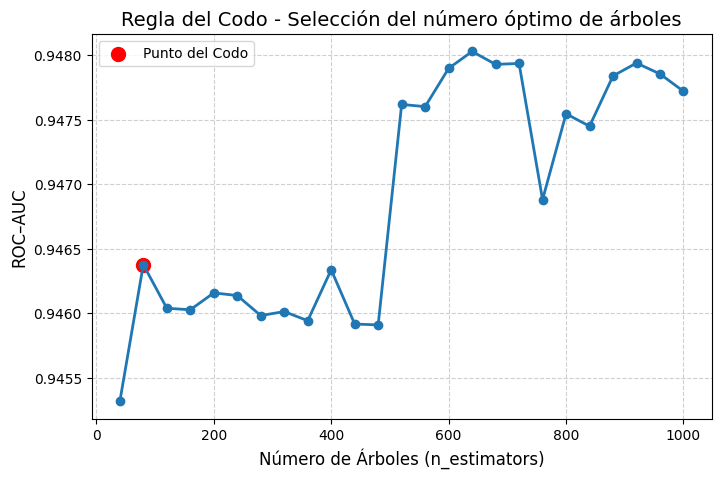

In [ ]:

# ==========================================
# 5. Gráfico ROC–AUC vs Número de Árboles
# ==========================================
plt.figure(figsize=(8,5))
plt.plot(n_estimators_range, roc_auc_values, marker='o', linewidth=2)
plt.scatter(optimal_n, roc_auc_values[elbow_idx], color='red', s=100, label="Punto del Codo")
plt.title("Regla del Codo - Selección del número óptimo de árboles", fontsize=14)
plt.xlabel("Número de Árboles (n_estimators)", fontsize=12)
plt.ylabel("ROC–AUC", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

In [ ]:
# ==========================================
# 6. Entrenar el modelo final y graficar curva ROC
# ==========================================
final_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=optimal_n,
    random_state=42
)
final_model.fit(X_train, y_train)
y_pred_prob = final_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})", linewidth=2)
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Modelo AdaBoost (Dataset Default)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()